# FedPome: pomegranate disease classification with the deployed ViT-B ONNX model

Reproduction of the inference path of **"FedPome: federated deep learning for real-time pomegranate disease classification"**
(*Frontiers in Plant Science* 17:1906269, 2026, [DOI](https://doi.org/10.3389/fpls.2026.1906269) | [PMC13558184](https://pmc.ncbi.nlm.nih.gov/articles/PMC13558184/)).

- **Purpose:** run the authors' packaged `ViT-B.onnx` classifier (the model deployed in their public
  [PomDetect Hugging Face Space](https://huggingface.co/spaces/lokes123/pomdetect)) on real images from the paper's
  [Mendeley dataset](https://data.mendeley.com/datasets/b6s2rkpmvh/1) (CC BY 4.0), exactly reproducing the preprocessing and softmax of the
  authors' Flask app (`ModelManager.predict` in `app.py`).
- **Scope (partial demonstration):** inference only, on **5 images (one per class)**. The federated
  training pipeline, the five other architectures, and the reported test accuracies are **out of scope**
  (no training code or split manifest is published; only `ViT-B.onnx` is packaged).
- **Execution status:** validated end-to-end on a fresh **CPU** Google Colab runtime
  (the authors' own deployment uses the ONNX Runtime `CPUExecutionProvider`). A GPU is **not** needed.
- **Downloads:** ~343 MB ONNX model + **~4.5 GB** Mendeley RAR (the dataset is published as a single
  archive; it is streamed, a few images are extracted, and the archive is deleted).

**日本語的要約:** 論文で公開されているポメグラヌ（ザクロ）果実病害5クラス分類のデプロイ済み `ViT-B.onnx`
モデルを、著者アプリ `app.py` の前処理・ソフトマックスをそのまま用いて CPU 上で実行します。入力は
Mendeley データセット（CC BY 4.0）の各クラス1枚ずつ・計5枚です。連合学習の学習再現は対象外です。

## Runtime selection — use a **CPU** runtime

`Runtime → Change runtime type → CPU` (the recommended and validated option), then
`Runtime → Run all`. The authors' Docker deployment runs inference with
`onnxruntime` on `CPUExecutionProvider` (`app.py` line 349), and the paper's Table 8 reports
~405 ms CPU latency for ViT-B, so faithful reproduction needs no GPU. Expected wall time on a fresh
CPU runtime: roughly 5–15 minutes, dominated by the ~4.5 GB dataset archive download.

**日本語:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してから「すべてのセルを実行」してください。
著者のデプロイも CPU（ONNX Runtime）なので GPU は不要です。所要時間の目安は 5〜15 分（大部分は
データセット RAR 約4.5 GB のダウンロード）。

## 1. Environment setup

**Expected result:** `onnxruntime`, `numpy`, and `pillow` are installed (all three are in the
authors' `requirements.txt`) and their versions are printed.

**日本語:** 著者の `requirements.txt` と同じ依存（onnxruntime / numpy / pillow）を整えます。

In [ ]:
%pip install -q --no-input onnxruntime numpy pillow
import numpy, PIL, onnxruntime, sys
print("python", sys.version.split()[0])
print("onnxruntime", onnxruntime.__version__)
print("numpy", numpy.__version__)
print("pillow", PIL.__version__)

python 3.13.16
onnxruntime 1.30.0
numpy 2.1.3
pillow 11.3.0


## 2. Download the deployed ViT-B ONNX model

**Expected result:** `ViT-B.onnx` (343,346,207 bytes) is downloaded from the authors' Space pinned to
commit `c9ecf84cb24ee28d27bffde65950f1524fac8bbe` and its SHA-256 must equal `9b02a7c92f7aacbc735314550e9925f9330905346454e1a254152d214c9a5320`; a truncated transfer is re-downloaded (up to
3 attempts) and the cell aborts if integrity still fails.

**日本語:** 著者の Hugging Face Space（コミット固定）から `ViT-B.onnx`（約343 MB）を取得し、
SHA-256 とサイズを検証します。一致しない場合は中断します。

In [ ]:
import hashlib, pathlib, urllib.request

ONNX_URL = "https://huggingface.co/spaces/lokes123/pomdetect/resolve/c9ecf84cb24ee28d27bffde65950f1524fac8bbe/ViT-B.onnx"
ONNX_SHA256 = "9b02a7c92f7aacbc735314550e9925f9330905346454e1a254152d214c9a5320"
ONNX_SIZE = 343346207
dst = pathlib.Path("/content/ViT-B.onnx")

def fetch(url, out, chunk=1 << 20):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-reproduction/1.0"})
    done = 0
    with urllib.request.urlopen(req, timeout=120) as r, open(out, "wb") as f:
        while True:
            b = r.read(chunk)
            if not b:
                break
            f.write(b)
            done += len(b)
            if done % (200 << 20) < chunk:
                print(f"  {done/1e6:.0f} MB", flush=True)
    return done

def fetch_verified(url, out, expected_size, expected_sha, tries=3):
    # transient truncations were observed on Colab; re-download and re-check up to 3 times
    for attempt in range(1, tries + 1):
        n = fetch(url, out)
        sha = hashlib.sha256(out.read_bytes()).hexdigest()
        ok = n == expected_size and sha == expected_sha
        print(f"attempt {attempt}: size={n}/{expected_size} sha_ok={sha == expected_sha}")
        if ok:
            return n, sha
    raise AssertionError(f"download failed integrity check after {tries} attempts")

print("downloading", ONNX_URL)
fetch_verified(ONNX_URL, dst, ONNX_SIZE, ONNX_SHA256)
print("ViT-B.onnx OK")

downloading https://huggingface.co/spaces/lokes123/pomdetect/resolve/c9ecf84cb24ee28d27bffde65950f1524fac8bbe/ViT-B.onnx


  210 MB


attempt 1: size=343346207/343346207 sha_ok=True
ViT-B.onnx OK


## 3. Load the model and inspect its input signature

**Expected result:** an ONNX Runtime session on `CPUExecutionProvider` (the same provider as the
authors' app) whose input is a float tensor named `input` with shape `1×3×224×224` and one output of
5 logits.

**日本語:** 著者アプリと同じ `CPUExecutionProvider` でモデルを読み込み、入出力の型と形状を確認します。

In [ ]:
import onnxruntime as ort

SESSION = ort.InferenceSession("/content/ViT-B.onnx", providers=["CPUExecutionProvider"])
assert SESSION.get_providers() == ["CPUExecutionProvider"], SESSION.get_providers()
inp, out = SESSION.get_inputs()[0], SESSION.get_outputs()[0]
INPUT_NAME = inp.name
print("input :", INPUT_NAME, inp.type, inp.shape)
print("output:", out.name, out.type, out.shape)
assert inp.type == "tensor(float)" and list(inp.shape[1:]) == [3, 224, 224], inp.shape
assert out.shape[-1] == 5, out.shape
print("model signature OK, input name =", INPUT_NAME)

input : input tensor(float) ['batch_size', 3, 224, 224]
output: output tensor(float) ['batch_size', 5]
model signature OK, input name = input


## 4. Fetch one real image per class from the paper's Mendeley dataset

The paper's dataset (DOI 10.17632/b6s2rkpmvh.1, CC BY 4.0, 5,099 images in five folders) is published
as a **single ~4.5 GB RAR archive**, so obtaining any real sample requires streaming the whole archive
into the Colab VM. This notebook asks the Mendeley record API for the archive's published
size/SHA-256 and download URL; if the API refuses this client, it falls back to the **verified public
file URL** for file id `6024e2d9-58af-45f5-926c-23d380152deb` (taken from the record metadata, not
guessed). Either way the downloaded bytes must match the published size and SHA-256 exactly, and the
archive is deleted after extraction. The whole download stays on the Colab VM.

**Expected result:** `Pomegranate Diseases Dataset.rar` (4,494,003,101 bytes, SHA-256
`b45c9533d1dacba597ee7f971c07b92b2979e2d63142cf0440e85d0b556eb4cd`) downloaded to `/content`.

**日本語:** 論文の Mendeley データセットは単一の約4.5 GB RAR として公開されているため、実サンプル取得には
アーカイブ全体のストリーミングが必要です。レコード API で公開されているサイズと SHA-256 を照合し
（API が拒否する場合は確認済みの公開ファイル URL を使用）、検証後にアーカイブは削除します。

In [ ]:
import hashlib, json, pathlib, urllib.request

RECORD_API = "https://data.mendeley.com/public-api/datasets/b6s2rkpmvh/files?version=1&folder_id=root"
EXPECTED_SHA = "b45c9533d1dacba597ee7f971c07b92b2979e2d63142cf0440e85d0b556eb4cd"
EXPECTED_SIZE = 4494003101
FALLBACK_URL = "https://data.mendeley.com/public-files/datasets/b6s2rkpmvh/files/6024e2d9-58af-45f5-926c-23d380152deb/file_downloaded"

def get_json(url):
    for ua in ["Mozilla/5.0 (X11; Linux x86_64) colab-reproduction/1.0", "colab-reproduction/1.0"]:
        req = urllib.request.Request(url, headers={"Accept": "application/vnd.mendeley-dataset.1+json", "User-Agent": ua})
        try:
            return json.load(urllib.request.urlopen(req, timeout=60))
        except Exception as e:
            print(f"record API with UA={ua!r} failed: {e}")
    return None

files = get_json(RECORD_API)
if files:
    entry = next(f for f in files if f["filename"].lower().endswith(".rar"))
    print("record:", entry["filename"], entry["size"], "bytes")
    assert entry["size"] == EXPECTED_SIZE, entry["size"]
    url = entry["content_details"]["download_url"]
else:
    print("record API unavailable; using the verified public file URL from the record metadata")
    url = FALLBACK_URL

rar = pathlib.Path("/content/Pomegranate Diseases Dataset.rar")
print("streaming from Mendeley (about 4.5 GB) ...")
fetch_verified(url, rar, EXPECTED_SIZE, EXPECTED_SHA)  # bounded retry helper from section 2
print("dataset archive OK")

record: Pomegranate Diseases Dataset.rar 4494003101 bytes
streaming from Mendeley (about 4.5 GB) ...


  210 MB


  419 MB


  629 MB


  839 MB


...

  3775 MB


  3985 MB


  4194 MB


  4404 MB


attempt 1: size=4494003101/4494003101 sha_ok=True
dataset archive OK


## 5. Extract a deterministic five-image sample and delete the archive

**Expected result:** `apt-get update` refreshes package lists, then the `unar` package (providing
`lsar`/`unar`) is installed (skipped if already present); the archive
listing is read with `lsar`; for each of the five expected disease
classes the **lexicographically first** matching `.jpg` is extracted to `/content/samples/`, and the
4.5 GB archive is then deleted so the run leaves a small footprint. Folder/file names inside the
archive are discovered at runtime (never hard-coded here).

**日本語:** `apt-get update` の後に `unar` パッケージを導入し（既にあればスキップ）、`lsar` で
アーカイブ一覧を取得して、各クラスで辞書順最初の `.jpg` を1枚ずつ `/content/samples/` に展開します。
その後 RAR 本体は削除します。

In [ ]:
import re, shutil, subprocess

def ensure_unar():
    # Colab images ship stale apt lists; update before install, and surface stderr on failure
    if shutil.which("lsar"):
        return
    r = subprocess.run(["apt-get", "-qq", "update"], capture_output=True, text=True, timeout=900)
    if r.returncode != 0:
        raise RuntimeError(f"apt-get update failed: {r.stderr[-500:]}")
    r = subprocess.run(["apt-get", "-qq", "install", "-y", "unar"], capture_output=True, text=True, timeout=900)
    if r.returncode != 0:
        raise RuntimeError(f"apt-get install unar failed: {r.stderr[-500:]}")

ensure_unar()
res = subprocess.run(["lsar", str(rar)], capture_output=True, text=True, timeout=600)
if res.returncode != 0:
    raise RuntimeError(f"lsar failed: {res.stderr[:500]}")
entries = [l.strip() for l in res.stdout.splitlines() if re.search(r"\.(jpe?g|png)$", l.strip(), re.I)]
print("image entries in archive:", len(entries))

EXPECTED = ["Alternaria", "Anthracnose", "Bacterial_Blight", "Cercospora", "Healthy"]
def norm(s):
    return re.sub(r"[\s_-]+", "_", s).lower()

samples, chosen = {}, {}
for name in sorted(entries):
    parts = pathlib.PurePosixPath(name).parts
    for cls in EXPECTED:
        if cls not in samples and any(cls.lower() in norm(p) for p in parts[:-1]):
            samples[cls] = name

missing = [c for c in EXPECTED if c not in samples]
assert not missing, f"no archive folder matched: {missing}"
for cls, name in samples.items():
    print(f"  {cls:18s} <- {name}")
    chosen[cls] = name

out_dir = pathlib.Path("/content/samples")
out_dir.mkdir(parents=True, exist_ok=True)
subprocess.run(["unar", "-q", "-f", "-o", str(out_dir), str(rar), *samples.values()],
               check=True, timeout=1800)
rar.unlink()
print("archive deleted; extracted:")

def find_extracted(name):
    # match the archive-relative suffix so same-basename files in different folders stay distinct
    matches = [p for p in out_dir.rglob("*") if p.is_file() and str(p).endswith(name)]
    assert len(matches) == 1, (name, matches)
    return matches[0]

sample_files = {cls: find_extracted(name) for cls, name in chosen.items()}
for cls, p in sample_files.items():
    print(f"  {cls:18s} {p} ({p.stat().st_size} bytes)")

image entries in archive: 5099
  Alternaria         <- Pomegranate Diseases Dataset/Alternaria/IMG_20230813_151711_1.jpg
  Anthracnose        <- Pomegranate Diseases Dataset/Anthracnose/IMG_20230813_151540_1.jpg
  Bacterial_Blight   <- Pomegranate Diseases Dataset/Bacterial_Blight/IMG_20230813_090023.jpg
  Cercospora         <- Pomegranate Diseases Dataset/Cercospora/IMG_20230813_151726.jpg
  Healthy            <- Pomegranate Diseases Dataset/Healthy/IMG_20230910_102205.jpg


archive deleted; extracted:
  Alternaria         /content/samples/Pomegranate Diseases Dataset/Alternaria/IMG_20230813_151711_1.jpg (1041625 bytes)
  Anthracnose        /content/samples/Pomegranate Diseases Dataset/Anthracnose/IMG_20230813_151540_1.jpg (767621 bytes)
  Bacterial_Blight   /content/samples/Pomegranate Diseases Dataset/Bacterial_Blight/IMG_20230813_090023.jpg (963669 bytes)
  Cercospora         /content/samples/Pomegranate Diseases Dataset/Cercospora/IMG_20230813_151726.jpg (1004303 bytes)
  Healthy            /content/samples/Pomegranate Diseases Dataset/Healthy/IMG_20230910_102205.jpg (881759 bytes)


## 6. Preview the five input images with their true labels

**Expected result:** a five-panel figure of the actual dataset images used below, each captioned with
its dataset class label (ground truth from the folder name, not a model output).

**日本語:** これから使う5枚の実画像を、データセットのフォルダ名に基づく正解ラベル付きで表示します
（モデル出力ではありません）。

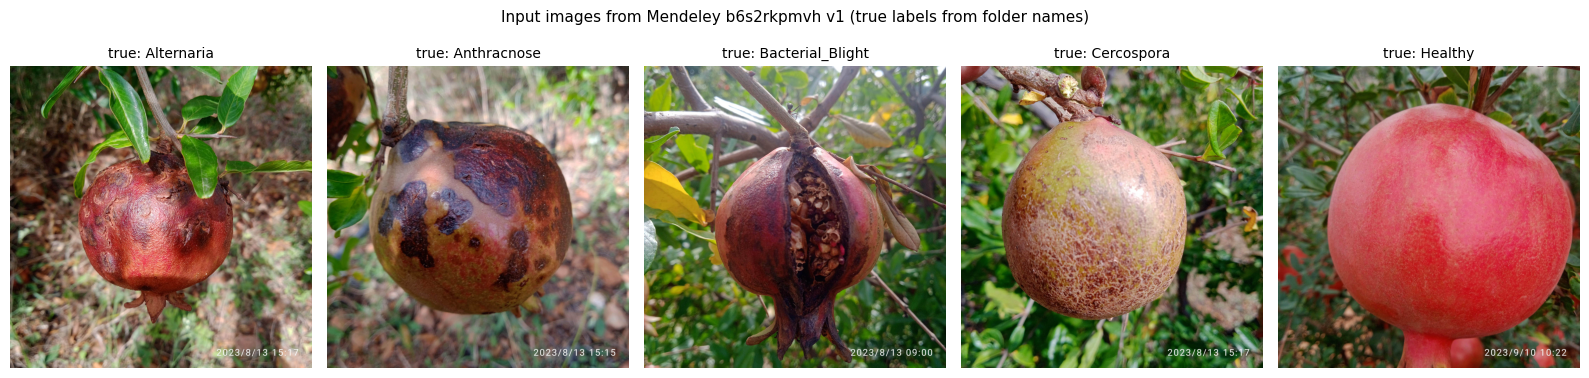

Alternaria         3120x3120 px, IMG_20230813_151711_1.jpg
Anthracnose        3120x3120 px, IMG_20230813_151540_1.jpg
Bacterial_Blight   3120x3120 px, IMG_20230813_090023.jpg
Cercospora         3120x3120 px, IMG_20230813_151726.jpg
Healthy            3120x3120 px, IMG_20230910_102205.jpg


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Input images from Mendeley b6s2rkpmvh v1 (true labels from folder names)", fontsize=11)
for ax, (cls, path) in zip(axes, sample_files.items()):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"true: {cls}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs_input_preview.png", dpi=90, bbox_inches="tight")
plt.show()
for cls, path in sample_files.items():
    im = Image.open(path)
    print(f"{cls:18s} {im.size[0]}x{im.size[1]} px, {path.name}")

## 7. Run the author's inference path on each image

This cell is a **verbatim port** of `ModelManager.predict` from the authors' `app.py`
(commit `c9ecf84cb24ee28d27bffde65950f1524fac8bbe`, lines 371–391): RGB conversion, `resize((224, 224))`, `/255`, ImageNet
mean/std normalization, CHW transpose, batch dimension, session run on the discovered input name,
then a stable softmax. Only the Flask wrapper was removed — the numerical operations are unchanged.

**Expected result:** a table of true label vs. prediction, confidence, and per-image inference time;
with a correctly trained model, most of the five predictions should match the folder labels
(a single-example run does **not** verify the paper's reported 98.83% test accuracy).

**日本語:** 著者 `app.py` の `ModelManager.predict`（371–391行）を数値操作はそのままに移植し、
5枚に対して推論します。出力は正解ラベル対予測・信頼度・推論時間の表です。

In [ ]:
import time
import numpy as np

CLASS_NAMES = ["Alternaria", "Anthracnose", "Bacterial_Blight", "Cercospora", "Healthy"]
IMG_SIZE = 224
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def predict(image, session, input_name):
    # verbatim numerical path of app.py ModelManager.predict (lines 374-391)
    img = image.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - MEAN) / STD
    arr = arr.transpose(2, 0, 1)[np.newaxis]
    t0 = time.time()
    out = session.run(None, {input_name: arr})[0][0]
    ms = (time.time() - t0) * 1000
    e = np.exp(out - out.max())
    p = e / e.sum()
    idx = int(p.argmax())
    return {
        "prediction": CLASS_NAMES[idx],
        "confidence": float(p[idx]) * 100,
        "probabilities": {c: round(float(v) * 100, 2) for c, v in zip(CLASS_NAMES, p)},
        "inference_ms": round(ms, 1),
    }

results = []
for cls, path in sample_files.items():
    r = predict(Image.open(path), SESSION, INPUT_NAME)
    r["true"] = cls
    results.append(r)

ms_all = [r["inference_ms"] for r in results]
print(f"per-image inference time (first run, CPU): {min(ms_all):.0f}-{max(ms_all):.0f} ms "
      f"(paper Table 8 reference: ~405 ms CPU for ViT-B)")
print()
w = max(len(r["true"]) for r in results) + 2
print(f"{'true':<{w}}{'predicted':<{w}}{'conf %':>8}  match  ms")
for r in results:
    print(f"{r['true']:<{w}}{r['prediction']:<{w}}{r['confidence']:>8.2f}  "
          f"{'YES' if r['prediction'] == r['true'] else 'no ':>5}  {r['inference_ms']:.0f}")
n_match = sum(r["prediction"] == r["true"] for r in results)
print(f"\n{n_match}/5 predictions match the dataset folder labels")

per-image inference time (first run, CPU): 399-528 ms (paper Table 8 reference: ~405 ms CPU for ViT-B)

true              predicted           conf %  match  ms
Alternaria        Alternaria           99.67    YES  528
Anthracnose       Anthracnose          99.26    YES  410
Bacterial_Blight  Bacterial_Blight     99.98    YES  399
Cercospora        Cercospora           99.99    YES  410
Healthy           Healthy              99.99    YES  410

5/5 predictions match the dataset folder labels


## 8. Visualization: input vs. model prediction and class probabilities

**Expected result:** two saved figures — (a) each input image overlaid with the model's predicted
class and confidence (green = matches the dataset label, red = mismatch; model predictions are
labeled distinctly from the true labels), and (b) a probability bar chart per image. These plots are
generated in this notebook for readability; they are not author figures.

**日本語:** 入力画像に予測クラスと信頼度を重畳した図（緑=正解一致、赤=不一致）と、各画像の
クラス確率の棒グラフを保存・表示します。本ノートブックで生成した可視化であり、論文の図ではありません。

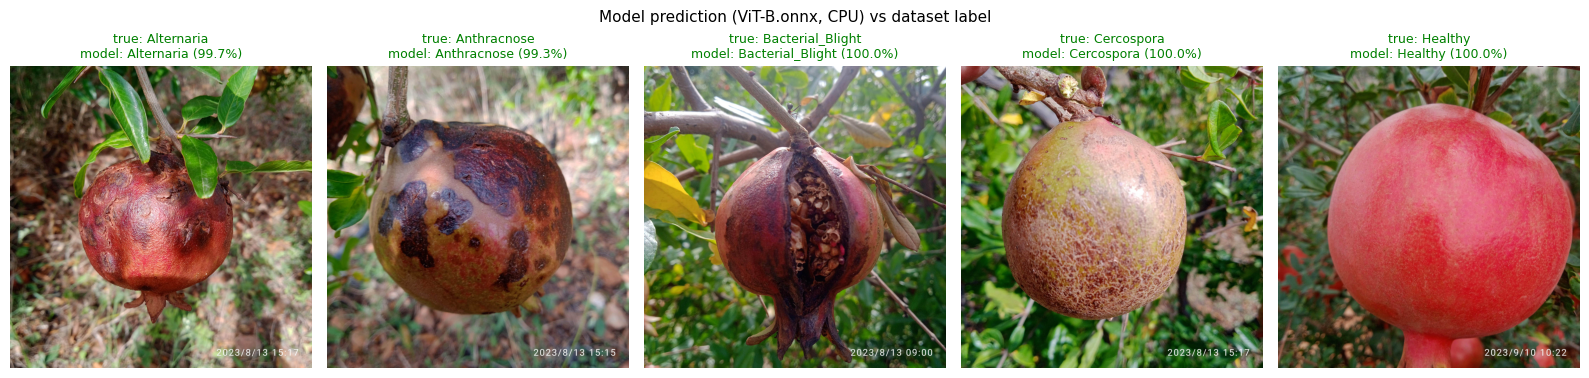

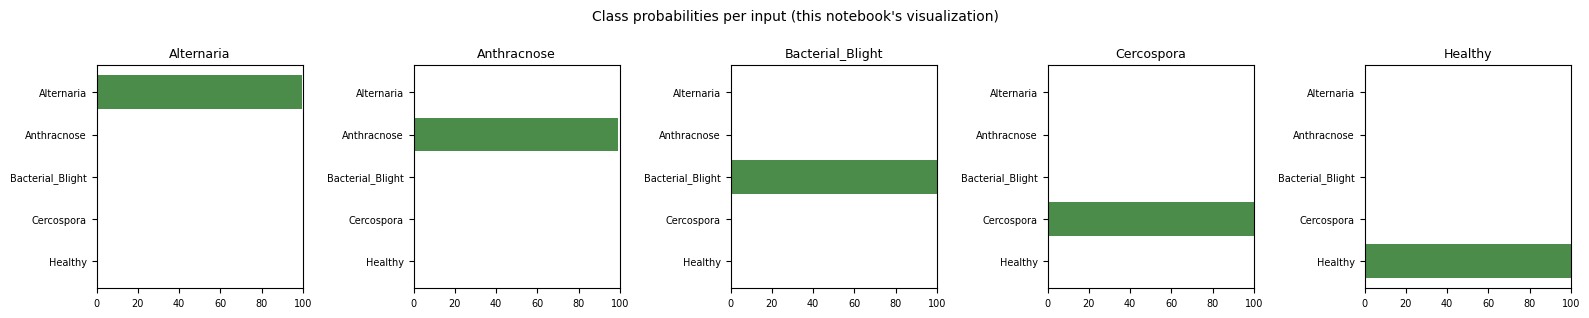

saved: outputs_input_preview.png, outputs_input_vs_prediction.png, outputs_probabilities.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# (a) input images with model predictions overlaid
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Model prediction (ViT-B.onnx, CPU) vs dataset label", fontsize=11)
for ax, r in zip(axes, results):
    img = Image.open(sample_files[r["true"]])
    ax.imshow(img)
    ok = r["prediction"] == r["true"]
    ax.set_title(f"true: {r['true']}\nmodel: {r['prediction']} ({r['confidence']:.1f}%)",
                 fontsize=9, color="green" if ok else "red")
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs_input_vs_prediction.png", dpi=90, bbox_inches="tight")
plt.show()

# (b) class probability bar chart (AI-generated visualization for this notebook)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, r in zip(axes, results):
    probs = [r["probabilities"][c] for c in CLASS_NAMES]
    ax.barh(CLASS_NAMES[::-1], probs[::-1], color="#4c8c4a")
    ax.set_title(r["true"], fontsize=9)
    ax.set_xlim(0, 100)
    ax.tick_params(labelsize=7)
fig.suptitle("Class probabilities per input (this notebook's visualization)", fontsize=10)
plt.tight_layout()
plt.savefig("/content/outputs_probabilities.png", dpi=90, bbox_inches="tight")
plt.show()
print("saved: outputs_input_preview.png, outputs_input_vs_prediction.png, outputs_probabilities.png")

## 9. Interpretation, limitations, and references

**What was reproduced:** the deployed inference path of FedPome (paper Sections 3.7/4.9) — the exact
`ViT-B.onnx` checkpoint the authors ship in their public PomDetect Space, with the exact
`ModelManager.predict` preprocessing (224×224 resize, ImageNet normalization, softmax over the five
classes `["Alternaria", "Anthracnose", "Bacterial_Blight", "Cercospora", "Healthy"]`), executed on
real images from the paper's own Mendeley dataset.

**Differences from the paper (recorded, not hidden):**
- The paper's training pipeline (Section 3.2) resized with GPU-accelerated **bilinear + antialiasing**;
  the deployed app uses PIL's default resize filter. This notebook follows the **app** because that is
  the released inference path.
- Only `ViT-B.onnx` is published; the five other architectures' ONNX files and all federated training
  code are not (data availability: "upon reasonable request"), so no accuracy benchmark is attempted.
- The exact seed-42 test split is unpublished, so the reported 98.83% ViT-B accuracy (Table 3) cannot
  be checked from these five images; the match/mismatch table above is a sanity check only.

**Limitations:** 5 images of 5,099; first-run timings vary with VM load (paper Table 8 reports
~405 ms CPU for ViT-B); the Space's code and weights carry **no stated license**, while the dataset
is CC BY 4.0 — verify reuse terms before redistribution.

**References:**
- Paper: FedPome, *Front. Plant Sci.* 17:1906269 (2026). [DOI](https://doi.org/10.3389/fpls.2026.1906269) | [PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC13558184/)
- Code/weights: `https://huggingface.co/spaces/lokes123/pomdetect` @ commit `c9ecf84cb24ee28d27bffde65950f1524fac8bbe` (app.py sha256 `35a8c6b0…`)
- Dataset: [Mendeley Data b6s2rkpmvh v1](https://data.mendeley.com/datasets/b6s2rkpmvh/1) (CC BY 4.0), single RAR, sha256 `b45c9533…`

**日本語:** 本ノートブックは論文のデプロイ済み推論経路（3.7/4.9節）を5枚の実画像で再現したものです。
論文の学習パイプラインや他モデル、報告精度の検証は対象外です（学習コード・他モデル重み・分割表は非公開）。
Space のコード/重みにはライセンス表記がなく、データセットは CC BY 4.0 です。